# 3.0 Model training - Ridge


## Imports


In [1]:
import numpy as np
import pandas as pd
import joblib
import json
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error
from sklearn.model_selection import train_test_split

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    create_model_gridsearch
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred
from recruit_restaurant_visitor_forecasting.utils import merge_daily_pred, convert_to_serializable,get_format
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2025-12-24 22:34:40.393 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
ALPHA = 1000
CV_SPLITS = 5
TEST_SIZE = 0.2
DROP_COLUMNS = [AIR_RESTAURANT_ID_COL, VISIT_DATE_COL, VISITORS_NBR_COL, DAY_OF_WEEK_COL, CITY_COL]

MODEL_PATH = MODELS_DIR / "ridge_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")

Features shape: (271221, 50)
Labels shape: (271221,)


In [4]:
original_index = features.index.copy()
features = prepare_features(features)

labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [5]:
dates = features[VISIT_DATE_COL].copy()
X = features
y = labels

In [6]:
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, shuffle=False, random_state=42
)
X_train = X_train_full.drop(columns=DROP_COLUMNS)
X_test = X_test_full.drop(columns=DROP_COLUMNS)

split_idx = len(X_train)
train_dates = dates.iloc[:split_idx].reset_index(drop=True)
test_dates = dates.iloc[split_idx:].reset_index(drop=True)

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-02-16 00:00:00
Test set dates: 2017-02-16 00:00:00 to 2017-04-22 00:00:00


## Training


In [7]:
grid_search = create_model_gridsearch(verbose=2, n_jobs=6, drop_features=DROP_COLUMNS)
grid_search.fit(X_train_full, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Best parameters: {'ridge__alpha': np.float64(10000.0), 'selector__estimator__alpha': np.float64(0.01), 'selector__threshold': 0.001}
Best score: -11.484340719886479


In [8]:
pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score").head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ridge__alpha,param_selector__estimator__alpha,param_selector__threshold,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
190,3.716418,0.834424,0.041142,0.002419,10000.0,0.010,0.001,"{'ridge__alpha': 10000.0, 'selector__estimator...",-11.486215,-10.606070,-10.767176,-12.772528,-11.789714,-11.484341,0.779534,1
191,3.966218,0.926322,0.042370,0.002469,10000.0,0.010,0.0001,"{'ridge__alpha': 10000.0, 'selector__estimator...",-11.486215,-10.606070,-10.767176,-12.772528,-11.789714,-11.484341,0.779534,1
189,3.819048,0.830406,0.038977,0.001036,10000.0,0.010,0.01,"{'ridge__alpha': 10000.0, 'selector__estimator...",-11.486215,-10.606607,-10.767176,-12.773614,-11.804928,-11.487708,0.780985,3
183,10.367813,1.936045,0.045956,0.002741,10000.0,0.001,0.01,"{'ridge__alpha': 10000.0, 'selector__estimator...",-11.488399,-10.605557,-10.768487,-12.776993,-11.810031,-11.489893,0.782508,4
185,10.264848,2.042786,0.052556,0.002936,10000.0,0.001,0.0001,"{'ridge__alpha': 10000.0, 'selector__estimator...",-11.488922,-10.605987,-10.768487,-12.776993,-11.810031,-11.490084,0.782411,5


In [9]:
model = grid_search.best_estimator_
sel = model.named_steps.get("selector", None)
support = sel.get_support()
selected_cols = X_train.columns[support]

print("Selected features:", list(selected_cols))

Selected features: ['opened_recently', 'holiday_flg', 'days_from_holiday', 'golden_week_flg', 'open_usually', 'days_from_last_visit', 'air_city_te', 'air_genre_te', 'total_reserves', 'total_reserves_nbrs', 'visitors_mean_7', 'visitors_median_7', 'visitors_std_7', 'visitors_mean_14', 'visitors_median_14', 'visitors_std_14', 'visitors_mean_28', 'visitors_std_28', 'visitors_nbrs_mean_7', 'visitors_nbrs_std_7', 'visitors_nbrs_mean_14', 'visitors_nbrs_median_14', 'visitors_nbrs_std_14', 'visitors_nbrs_mean_28', 'visitors_nbrs_median_28', 'visitors_nbrs_std_28', 'visitors_last_month', 'visitors_lag_1', 'visitors_lag_7', 'visitors_lag_28', 'visitors_nbrs_lag_1', 'visitors_nbrs_lag_7', 'visitors_nbrs_lag_28', 'visitors_dow_mean', 'visitors_dow_mean_nbrs', 'res_visitors_diff', 'res_visitors_diff_mean_14', 'nbr_res_visitors_diff', 'nbr_res_visitors_diff_mean_7', 'nbr_res_visitors_diff_mean_14', 'nbr_res_visitors_diff_mean_28']


In [10]:
y_train_pred = model.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")
print(f"R2:   {train_r2:.4f}")

Train set metrics:
RMSLE: 0.9230
MAE:  7.2323
R2:   0.5639


In [8]:
y_test_pred, temp_features = recursive_predict(
    model,
    X_test_full,
    X_train_full,
    y_train,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively:   0%|          | 0/66 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[22.58251893  4.01521181 16.62718737  4.66263955 16.3922476  21.07499795
 19.45459375 22.13715972 35.39891382 12.6281805   5.55423182 16.98722835
 14.9191109  14.18842968 26.19434383  5.66948929 25.82226204 23.81692168
 15.62605698 12.4953457  15.5171024  29.81929214 11.0059211  52.35620914
 11.31328245 11.91427724  5.15504779  8.90040466  0.         10.87794137
 25.36422487 14.60209538 28.26173627  8.68276654 32.41249813 15.78907699
 43.64644102 13.32946693 18.40538502 28.08670092 14.19106058 26.79551589
  1.95260088 28.89831568 11.15165958  7.72788118 12.74685553  7.00238195
 17.51447654 20.06540919 28.74795178  2.56233497  2.31510692 24.69029644
 13.26326422  5.23822012 33.22994322  7.68591199  7.30810696 23.149

In [9]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R2:   {test_r2:.4f}")


Test set metrics:
RMSLE: 0.8789
MAE:  7.5523
R2:   0.5370


## Graphs

### Visitors per day: actual vs predicted

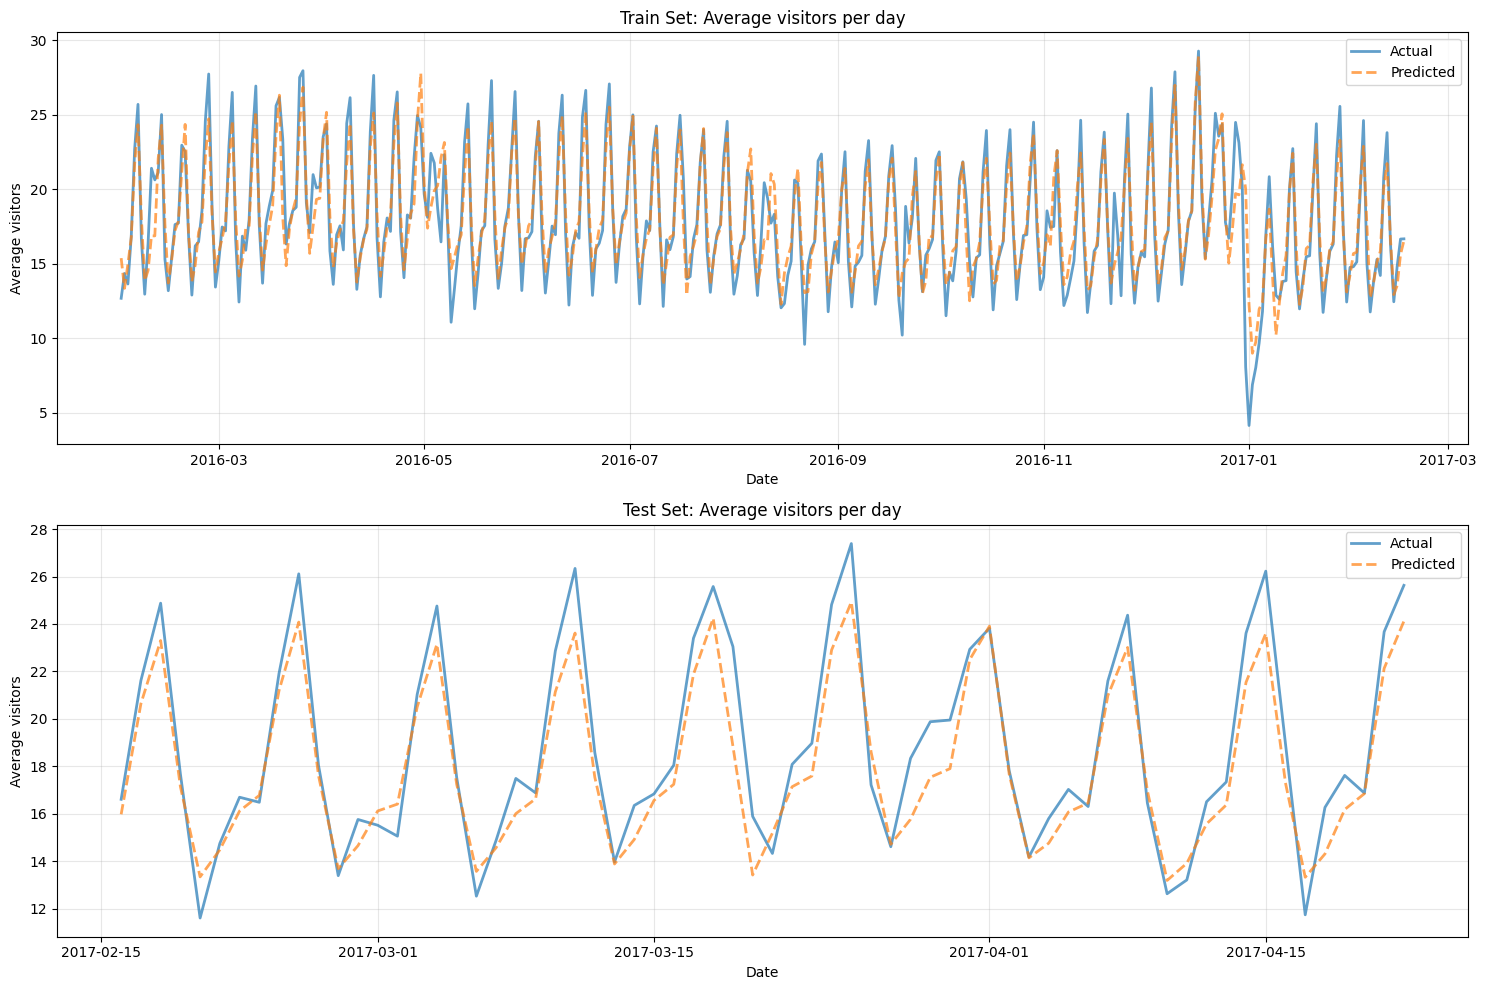

In [12]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [7]:
model = joblib.load(MODEL_PATH)

In [18]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)

In [19]:
test_labels, temp_features = recursive_predict(
    model,
    test_features,
    X,
    y,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively:   0%|          | 0/39 [00:00<?, ?it/s]C:\Users\lymuthien\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[3.18642449e+00 0.00000000e+00 1.04921221e+01 6.29277827e+00
 2.39866476e+01 2.60008095e+01 2.68210140e+01 7.26226667e+00
 3.77612998e+01 2.29272401e+00 2.50327210e+01 5.11087575e+00
 2.97733842e+01 4.67489879e+01 2.47574984e+01 5.99309922e+00
 1.53579164e+01 1.21390260e+01 2.47319996e+01 4.80240510e+01
 7.32583465e+00 1.62913510e+01 1.51298506e+01 1.79621829e+01
 3.17202433e-01 2.81865974e+01 1.34270759e+01 1.98535950e+01
 3.28643935e-02 1.50979724e+01 2.11921016e+01 8.75433145e+00
 2.046548

In [20]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [15]:
joblib.dump(model, MODEL_PATH)

params_to_save = {
    "best_params": convert_to_serializable(grid_search.best_params_),
    "best_score": float(grid_search.best_score_),
    "selected_features": list(selected_cols) if 'selected_cols' in globals() else None,
    "n_features": len(selected_cols) if 'selected_cols' in globals() else None,
}

params_path = MODELS_DIR / "ridge_model_params.json"
with open(params_path, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)